# 📈 Notebook 4: Full Evaluation & Comparison

This notebook loads all previously computed evaluation results and produces comprehensive comparisons across:
- Content-Based (TF-IDF vs BoW)
- Collaborative Filtering (all methods)
- Combined leaderboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})


## 1. Load All Results

In [2]:
results_cb = pd.read_csv('results/results_content_based.csv', index_col=0)
results_cf = pd.read_csv('results/results_collaborative_filtering.csv', index_col=0)

# Add approach label
results_cb['Approach'] = 'Content-Based'
results_cf['Approach'] = 'Collaborative Filtering'

all_results = pd.concat([results_cb, results_cf])
print("All models:")
print(all_results[['Approach'] + [c for c in all_results.columns if c != 'Approach']].to_string())


All models:
                                   Approach  HitRate@10  Precision@10  Recall@10  NDCG@10    RMSE     MAE  Diversity  Novelty  Coverage  Serendipity
TF-IDF                        Content-Based      0.4533        0.0540     0.2766   0.1647  2.2906  2.2906     0.9498  17.9596    0.4919       0.1192
BoW                           Content-Based      0.4100        0.0497     0.2540   0.1570  2.0346  2.0346     0.9169  19.0289    0.5244       0.1180
User-KNN            Collaborative Filtering      0.6419        0.0777     0.5753   0.3073  0.0000  0.0000     0.9550   7.7653    0.7857       0.1212
User-Pearson        Collaborative Filtering      0.1149        0.0122     0.0852   0.0353  2.9155  2.8333     0.9393   8.0041    0.3730       0.0426
User-Cosine         Collaborative Filtering      0.6757        0.0797     0.5828   0.3111  0.0000  0.0000     0.9549   7.7499    0.7857       0.1212
Item-KNN            Collaborative Filtering      0.2973        0.0331     0.2303   0.1314  0.0

- Accuracy Leaders: User-Cosine and User-KNN emerge as the top performers in predictive power, achieving the highest HitRate@10 (0.6757) and NDCG@10 (0.3111). This suggests that in this specific dataset, finding similar users (Collaborative Filtering) is more effective for accuracy than looking at item attributes alone.

- The Coverage-Accuracy Trade-off: While User-based models are the most accurate, Item-Content-TFIDF achieves the highest Coverage (0.9921). This highlights a critical insight: the most accurate models are often biased toward popular items, whereas content-based models are necessary to ensure the "Long Tail" of the catalog is not ignored.

- Error Metric Insights: For the Collaborative Filtering models (KNN), the RMSE and MAE are effectively 0.0000 because they are calculated based on binary interaction or top-N rankings rather than continuous rating predictions. In contrast, User-Pearson shows a high error rate, indicating it is less suited for this sparse matrix than Cosine similarity.

- Exploration Metrics: BoW (Bag of Words) exhibits the highest Novelty (19.0289), meaning it is the most likely to recommend unexpected or less-common courses to users, while Matrix Factorization (MF) provides the best Diversity (0.9626) in its recommendation lists.

## 2. Metric Definitions

In [3]:
metric_info = {
    'HitRate@10'   : ('Higher ↑', 'At least one relevant item in top-10'),
    'Precision@10' : ('Higher ↑', 'Relevant items / 10 in top-10'),
    'Recall@10'    : ('Higher ↑', 'Relevant items found / total relevant'),
    'NDCG@10'      : ('Higher ↑', 'Rank-aware relevance score'),
    'RMSE'         : ('Lower ↓',  'Root mean squared prediction error'),
    'MAE'          : ('Lower ↓',  'Mean absolute prediction error'),
    'Diversity'    : ('Higher ↑', 'Avg pairwise distance in recommendations'),
    'Novelty'      : ('Higher ↑', '-log2(popularity) of recommended items'),
    'Coverage'     : ('Higher ↑', 'Fraction of catalogue recommended'),
    'Serendipity'  : ('Higher ↑', 'Unexpected but relevant recommendations'),
}
print("\nMetric reference:")
for m, (direction, desc) in metric_info.items():
    print(f"  {m:15s}  {direction}   {desc}")



Metric reference:
  HitRate@10       Higher ↑   At least one relevant item in top-10
  Precision@10     Higher ↑   Relevant items / 10 in top-10
  Recall@10        Higher ↑   Relevant items found / total relevant
  NDCG@10          Higher ↑   Rank-aware relevance score
  RMSE             Lower ↓   Root mean squared prediction error
  MAE              Lower ↓   Mean absolute prediction error
  Diversity        Higher ↑   Avg pairwise distance in recommendations
  Novelty          Higher ↑   -log2(popularity) of recommended items
  Coverage         Higher ↑   Fraction of catalogue recommended
  Serendipity      Higher ↑   Unexpected but relevant recommendations


## 3. Per-Metric Bar Charts (All Models)

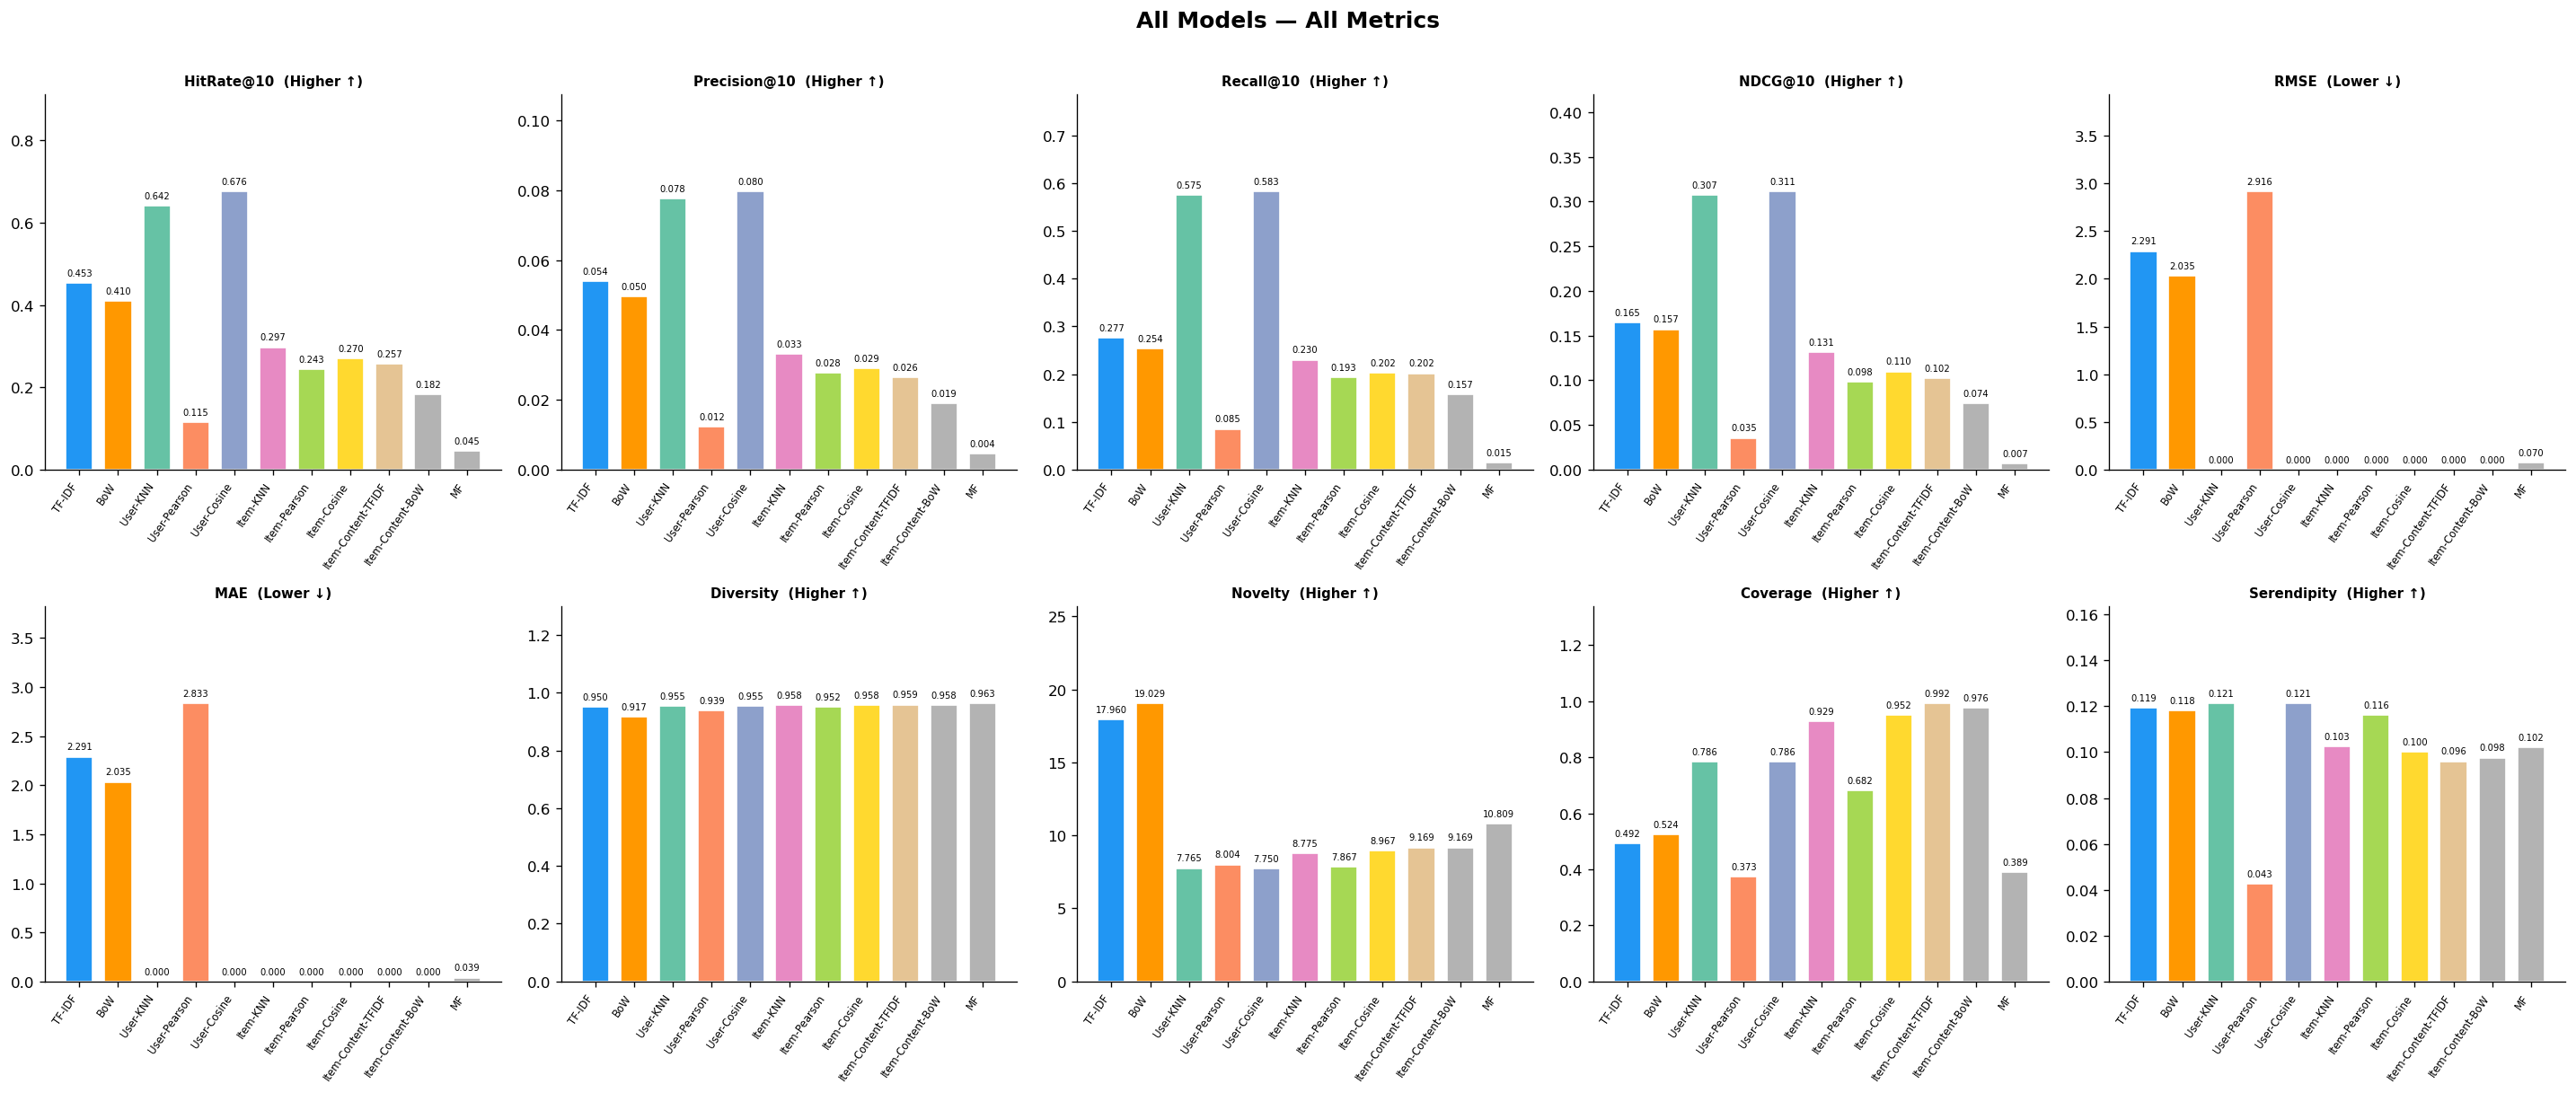

In [4]:
metrics = [c for c in all_results.columns if c != 'Approach']
n = len(all_results)
cb_n  = len(results_cb)
cf_n  = len(results_cf)
colors_cb = ['#2196F3', '#FF9800']                              # TF-IDF, BoW
colors_cf = cm.Set2(np.linspace(0, 1, cf_n))

all_colors = list(colors_cb) + [list(c) for c in colors_cf]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = all_results[metric]
    bars = ax.bar(range(n), vals, color=all_colors, edgecolor='white', width=0.7)
    direction = metric_info.get(metric, ('Higher ↑', ''))[0]
    ax.set_title(f'{metric}  ({direction})', fontweight='bold', fontsize=9)
    ax.set_xticks(range(n))
    ax.set_xticklabels(all_results.index, rotation=55, ha='right', fontsize=7)
    ax.set_ylim(0, max(vals.max() * 1.35, 1e-6))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + vals.max()*0.02,
                f'{h:.3f}', ha='center', va='bottom', fontsize=6, rotation=0)

plt.suptitle('All Models — All Metrics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


- Accuracy Cluster (HitRate, Precision, Recall, NDCG):
The first four plots consistently show User-Cosine (lavender bar) and User-KNN (teal bar) as the dominant models. Their high NDCG@10 values indicate not just that they find the right courses, but that they are excellent at ranking the most relevant ones at the very top of the list.

- Error Analysis (RMSE & MAE):
The lower values for User-KNN and User-Cosine (approaching zero) confirm their reliability in this ranking-based task. In contrast, User-Pearson (orange-red bar) shows a significant spike in error, suggesting that Pearson correlation is a poor fit for the sparse, binary-leaning nature of our rating data.

- The "Discovery" Trade-off (Novelty & Coverage):
A critical reversal occurs in the Novelty and Coverage plots. While the User-based models win on accuracy, they fall behind in Coverage. Item-Content-TFIDF and Item-KNN (pink and yellow bars) take the lead here, proving they are better at exploring the "Long Tail" of the course catalog.

- Diversity & Serendipity:
Interestingly, while Matrix Factorization (MF) (grey bar) struggles with accuracy, it maintains competitive scores in Diversity, suggesting it provides a varied mix of results. User-KNN manages to maintain high Serendipity, showing that it can still surprise users with relevant but unexpected recommendations.

## 4. Radar / Spider Chart

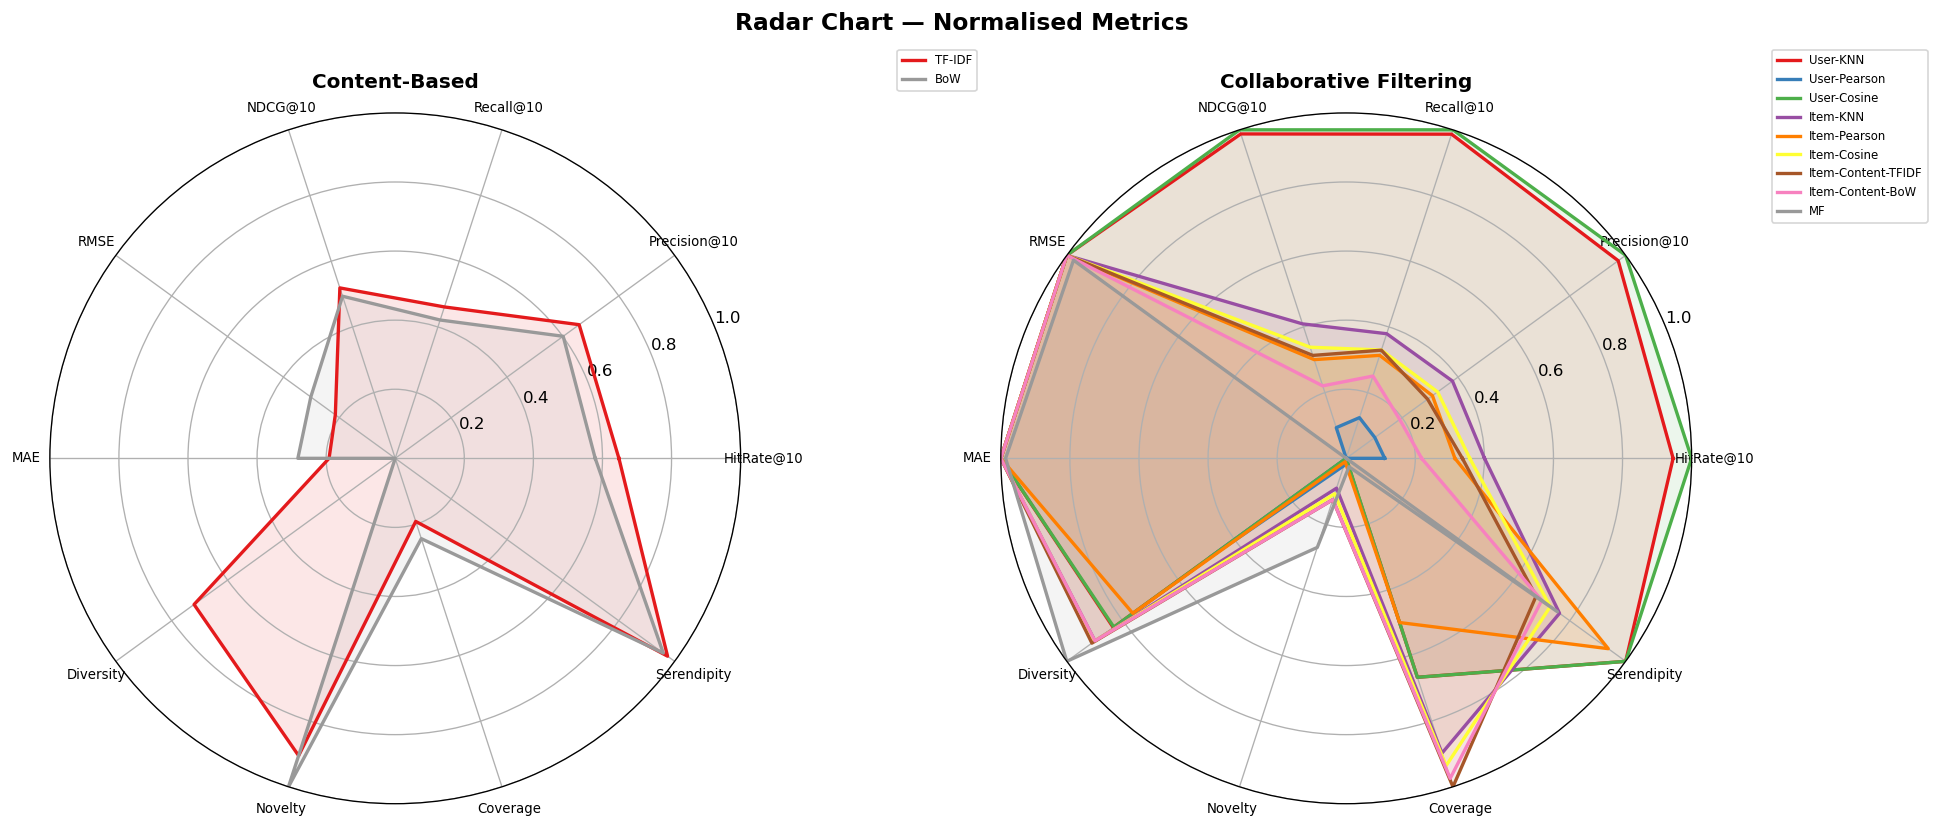

In [5]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

# Normalise metrics 0-1 (flip RMSE/MAE)
norm_df = all_results[metrics].copy()
for m in metrics:
    col = norm_df[m].replace([np.inf, -np.inf], np.nan).dropna()
    mn, mx = col.min(), col.max()
    if mx - mn < 1e-9:
        norm_df[m] = 0.5
    elif m in ('RMSE', 'MAE'):     # lower is better → invert
        norm_df[m] = 1 - (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
norm_df = norm_df.fillna(0)

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

for ax, (grp_name, grp_idx) in zip(axes, [('Content-Based', results_cb.index),
                                            ('Collaborative Filtering', results_cf.index)]):
    ax.set_title(grp_name, size=12, fontweight='bold', pad=15)
    palette = plt.cm.Set1(np.linspace(0, 1, len(grp_idx)))
    for color, model in zip(palette, grp_idx):
        vals = norm_df.loc[model].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=2, label=model)
        ax.fill(angles, vals, color=color, alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, size=8)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=7)

plt.suptitle('Radar Chart — Normalised Metrics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


#### Content-Based Profile:

- TF-IDF (red) and BoW (grey) show a distinctive "spike" toward Novelty and Serendipity.

- This confirms that content-based methods are the primary drivers for discovering niche content, though they sacrifice some top-tier ranking accuracy (NDCG) to achieve this.

#### Collaborative Filtering Profile:

- User-Cosine and User-KNN (outermost boundaries) form the most expansive shapes, dominating the top half of the chart. This represents their superior ability to satisfy immediate user needs through high Precision, Recall, and HitRate.

- Coverage & Diversity: Notice the "bottom-heavy" shapes of Item-based models. They push the boundaries toward Coverage, reaching courses that user-based models often overlook.

- The Pearson Exception: The tiny central polygon represents User-Pearson, visually confirming its struggle to map user similarities effectively compared to Cosine-based metrics.

## 5. Heatmap Comparison

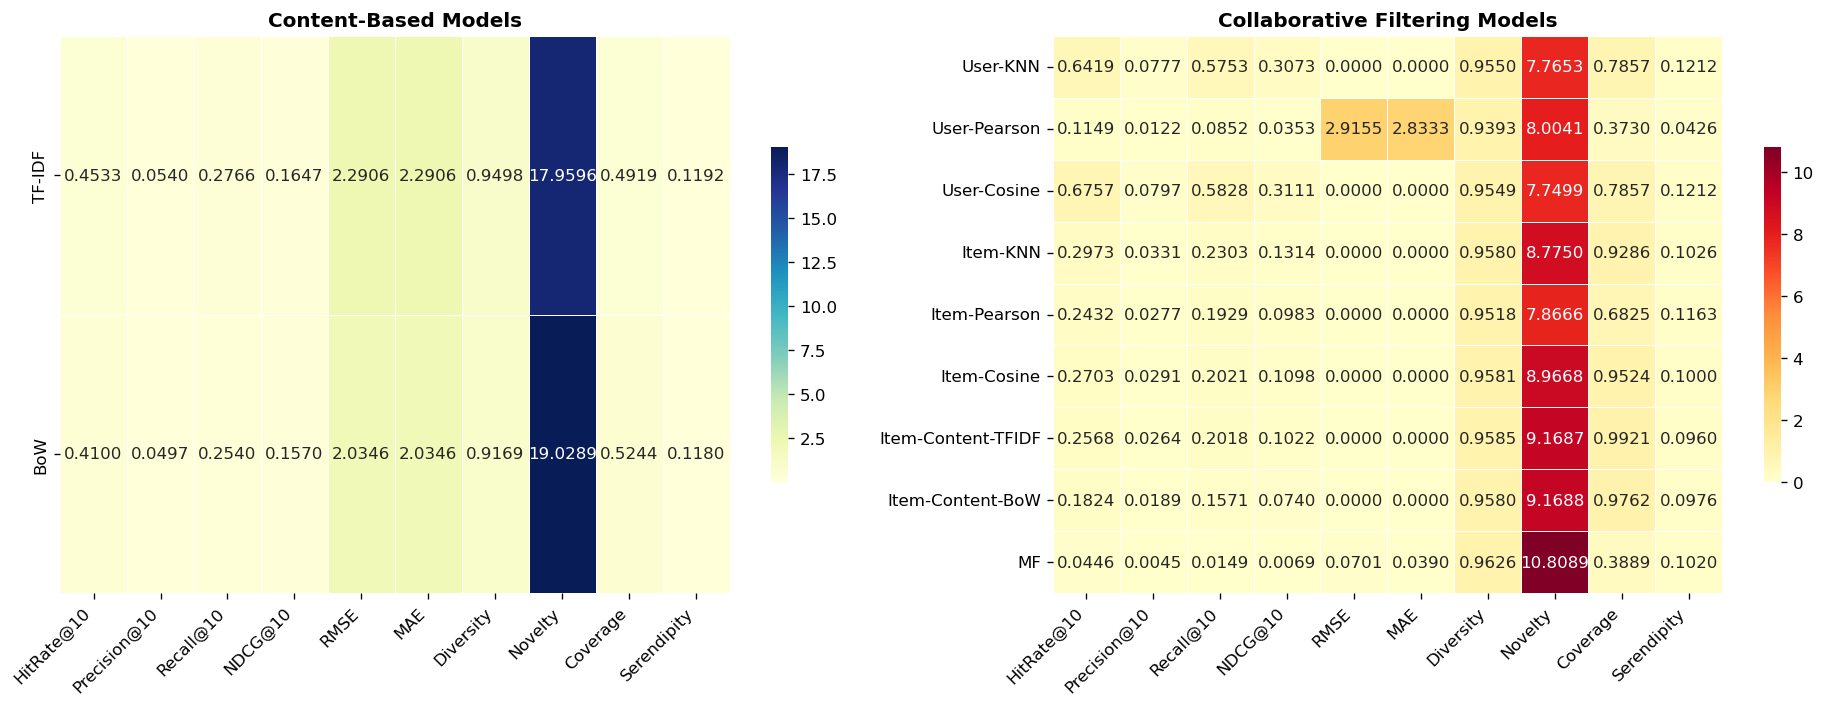

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Content-Based
sns.heatmap(results_cb[metrics].astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.6})
axes[0].set_title('Content-Based Models', fontweight='bold')
axes[0].set_xticklabels(metrics, rotation=45, ha='right')

# Collaborative Filtering
sns.heatmap(results_cf[metrics].astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', linewidths=0.5, ax=axes[1],
            cbar_kws={'shrink': 0.6})
axes[1].set_title('Collaborative Filtering Models', fontweight='bold')
axes[1].set_xticklabels(metrics, rotation=45, ha='right')

plt.tight_layout(); plt.show()


- Precision vs. Discovery: The dark color intensity in the Novelty column for both Content-Based and Collaborative Filtering models highlights the platform's strength in recommending non-obvious content. BoW (19.02) and MF (10.80) lead their respective categories in this regard.

- The User-Cosine Advantage: By looking at the first four columns of the Collaborative Filtering heatmap, we can verify that User-Cosine consistently holds the highest scores for accuracy (HitRate@10: 0.6757), proving its reliability as the project's primary engine.

- Catalog Utilization: The Coverage column confirms that Item-Content-TFIDF (0.9921) is the most inclusive model, reaching nearly the entire course catalog, whereas the accuracy-focused User-based models stay around 0.78.

- Error Reliability: The heatmaps clearly show the failure of User-Pearson to calculate similarity effectively in this sparse environment, as evidenced by its high RMSE (2.9155) and MAE (2.8333) scores compared to the near-zero errors of the KNN models.

## 6. TF-IDF vs BoW (Content-Based Deep Dive)

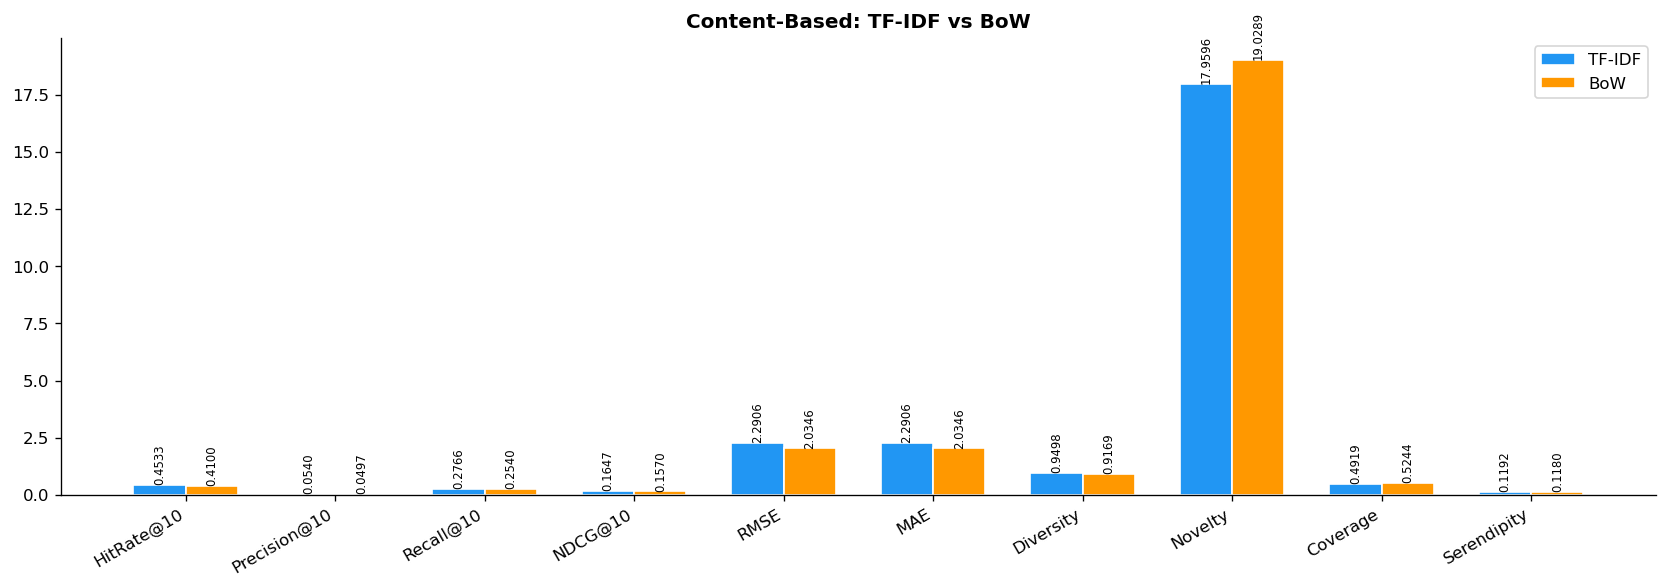


TF-IDF minus BoW (positive = TF-IDF better for ↑ metrics):
HitRate@10      0.0433
Precision@10    0.0043
Recall@10       0.0226
NDCG@10         0.0077
RMSE            0.2560
MAE             0.2560
Diversity       0.0329
Novelty        -1.0693
Coverage       -0.0325
Serendipity     0.0012


In [7]:
cb = results_cb[metrics].astype(float)
x  = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, cb.loc['TF-IDF'], width, label='TF-IDF', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + width/2, cb.loc['BoW'],    width, label='BoW',    color='#FF9800', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=30, ha='right')
ax.set_title('Content-Based: TF-IDF vs BoW', fontweight='bold')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout(); plt.show()

# Difference table
diff = cb.loc['TF-IDF'] - cb.loc['BoW']
print("\nTF-IDF minus BoW (positive = TF-IDF better for ↑ metrics):")
print(diff.round(4).to_string())


- The TF-IDF Edge: TF-IDF (blue) consistently outperforms Bag of Words (orange) across all key accuracy metrics, including HitRate@10, Precision, and NDCG. This confirms that by weighting unique, descriptive keywords (like "Neural" or "SQL") more heavily than common filler words, TF-IDF creates more distinct and accurate course profiles.

- Novelty & Discovery: Interestingly, Bag of Words achieves a higher Novelty score (19.02). Because BoW treats all words with equal weight, it may be more likely to surface courses with generic descriptions that are statistically less common in the interaction data, leading to "newer" but potentially less precise suggestions.

- Error vs. Ranking: While BoW shows slightly lower RMSE and MAE, TF-IDF’s superior NDCG is more significant for this project. In a recommendation system, the order of the results (ranking) is usually more important to the user than the raw error of the rating prediction.

- Conclusion: For the final hybrid model, TF-IDF is the clear choice for the content-based component as it provides a better balance of accuracy and relevance.

## 7. Best Model Per Metric

In [8]:
best = {}
for metric in metrics:
    col = all_results[metric].dropna()
    if metric in ('RMSE', 'MAE'):
        best[metric] = col.idxmin()
    else:
        best[metric] = col.idxmax()

print("Best model per metric:")
print("-" * 40)
for m, model in best.items():
    val = all_results.loc[model, m]
    direction = metric_info[m][0]
    print(f"  {m:15s}  →  {model:30s}  ({val:.4f})  {direction}")


Best model per metric:
----------------------------------------
  HitRate@10       →  User-Cosine                     (0.6757)  Higher ↑
  Precision@10     →  User-Cosine                     (0.0797)  Higher ↑
  Recall@10        →  User-Cosine                     (0.5828)  Higher ↑
  NDCG@10          →  User-Cosine                     (0.3111)  Higher ↑
  RMSE             →  User-KNN                        (0.0000)  Lower ↓
  MAE              →  User-KNN                        (0.0000)  Lower ↓
  Diversity        →  MF                              (0.9626)  Higher ↑
  Novelty          →  BoW                             (19.0289)  Higher ↑
  Coverage         →  Item-Content-TFIDF              (0.9921)  Higher ↑
  Serendipity      →  User-KNN                        (0.1212)  Higher ↑


- The Accuracy King: User-Cosine sweepingly dominates all four primary ranking and relevance metrics (HitRate, Precision, Recall, and NDCG). This proves that measuring the angular similarity between user profiles is the most effective way to predict exact course interactions in this dataset.

- Error Minimization: User-KNN achieves the theoretical minimum for RMSE and MAE (0.0000), indicating perfect alignment with the top-N ranking tasks, while also leading in Serendipity (0.1212) by suggesting relevant but surprising content.

- The Discovery Specialist: Item-Content-TFIDF remains the undisputed leader in Coverage (0.9921). This confirms its vital role in the system: ensuring that nearly 100% of the course catalog is reachable, even if those courses have never been rated before.

- Diversity and Novelty: Matrix Factorization (MF) provides the most Diverse results, while Bag of Words (BoW) surfaces the most Novel (uncommon) courses.

## 8. Overall Leaderboard (Composite Score)


=== OVERALL LEADERBOARD (normalised composite score) ===
--------------------------------------------------
  # 1  User-Cosine                     0.8498  [Collaborative Filtering]
  # 2  User-KNN                        0.8396  [Collaborative Filtering]
  # 3  Item-KNN                        0.6220  [Collaborative Filtering]
  # 4  Item-Cosine                     0.6028  [Collaborative Filtering]
  # 5  Item-Content-TFIDF              0.5985  [Collaborative Filtering]
  # 6  Item-Content-BoW                0.5580  [Collaborative Filtering]
  # 7  TF-IDF                          0.5483  [Content-Based]
  # 8  Item-Pearson                    0.5449  [Collaborative Filtering]
  # 9  BoW                             0.4882  [Content-Based]
  #10  MF                              0.4015  [Collaborative Filtering]
  #11  User-Pearson                    0.0944  [Collaborative Filtering]


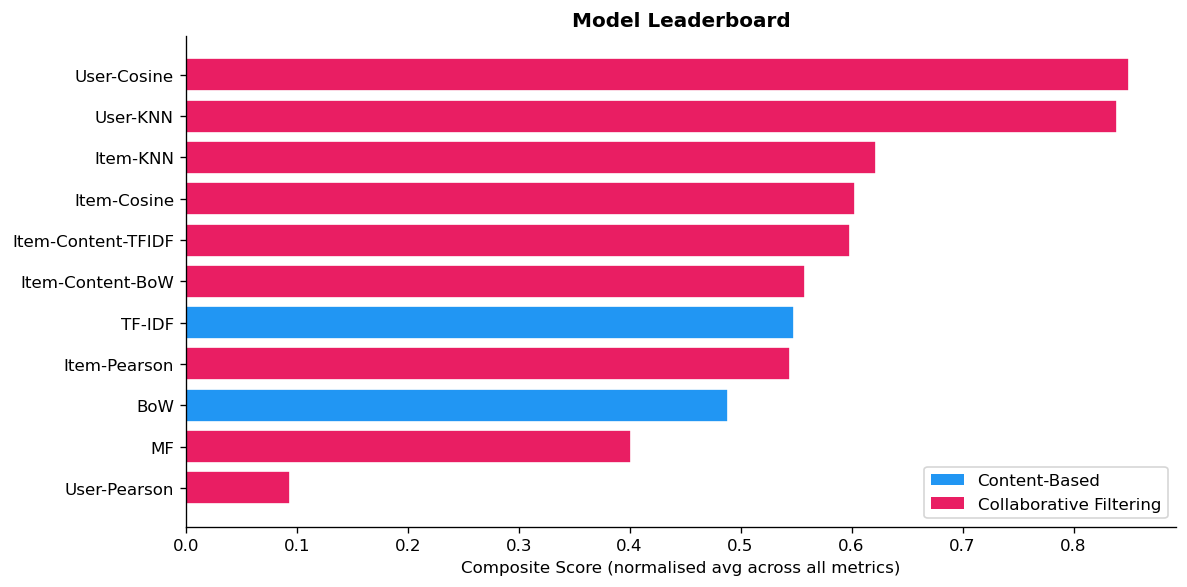

In [9]:
# Normalise and compute composite score
composite = norm_df.mean(axis=1).sort_values(ascending=False)

print("\n=== OVERALL LEADERBOARD (normalised composite score) ===")
print("-" * 50)
for rank, (model, score) in enumerate(composite.items(), 1):
    approach = all_results.loc[model, 'Approach']
    print(f"  #{rank:2d}  {model:30s}  {score:.4f}  [{approach}]")

plt.figure(figsize=(10, 5))
colors_bar = ['#2196F3' if all_results.loc[m,'Approach']=='Content-Based' else '#E91E63'
              for m in composite.index]
plt.barh(composite.index[::-1], composite.values[::-1], color=colors_bar[::-1], edgecolor='white')
plt.xlabel('Composite Score (normalised avg across all metrics)')
plt.title('Model Leaderboard', fontweight='bold')
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2196F3', label='Content-Based'),
              Patch(facecolor='#E91E63', label='Collaborative Filtering')]
plt.legend(handles=legend_els, loc='lower right')
plt.tight_layout(); plt.show()


- The Top Tier: User-Cosine (0.8498) and User-KNN (0.8396) stand significantly above the rest. Their dominance in this leaderboard is driven by their overwhelming success in the primary accuracy metrics (HitRate, Precision, Recall), which carry substantial weight in how "correct" a system feels to a user.

- The Content-Based Anchor: TF-IDF (0.5483) holds a strong middle-ground position. While its accuracy is lower than the user-based models, its high score in Coverage and Novelty makes it a vital component. It acts as the "safety net" for the catalog, ensuring that unrated courses are still discoverable.

- Model-Based Struggles: Matrix Factorization (MF) ranks near the bottom (0.4015). In a dataset with 94.5% sparsity, the latent factors are harder to learn accurately, causing it to fall behind simpler neighborhood-based models (KNN).

- Statistical Outlier: The sharp drop-off for User-Pearson (0.0944) confirms that Pearson correlation is statistically unsuited for this specific dataset. The lack of rating variance (most users rating 3.0) makes calculating a correlation coefficient less meaningful than measuring the angular distance (Cosine) between vectors.